In [1]:
from typing import Literal, Any
import torch

device: Literal['cpu', 'cuda'] = "cuda" if torch.cuda.is_available() else "cpu"
torch.cuda.get_device_name()

# gpu configureations → based on pytorch and cuda downloaded versions
if device == "cuda":
    print(torch.cuda.get_device_name())
    print(torch.__version__)
    print(torch.version.cuda)
    print(torch.backends.cudnn.version())
    print(torch.cuda.get_arch_list())
    print(torch.cuda.is_available())

# system gpu configurations
!nvidia-smi

NVIDIA GeForce MX350
2.14.0+cu126
12.6
91002
['sm_50', 'sm_60', 'sm_70', 'sm_75', 'sm_80', 'sm_86', 'sm_90']
True
Fri Oct  2 10:53:03 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.178.04             Driver Version: 580.178.04     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce MX350           Off |   00000000:01:00.0 Off |                  N/A |
| N/A   49C    P8            N/A  / 5001W |       4MiB /   2048MiB |      0%      Default |
|                         

In [2]:
from torchvision.transforms import v2
from torchvision.datasets import FashionMNIST
from torch.utils.data import Dataset

# Custom Dataset class
class CustomFashionMNIST(Dataset):
    def __init__(self: CustomFashionMNIST, type: str="train", transforms: v2 | None=None) -> None:
        """ Downloading pytorch's available dataset and applying transformations """

        # Defining transformations → https://docs.pytorch.org/vision/main/transforms.html
        self.transforms = transforms
        if self.transforms == None:
            self.transforms = v2.Compose(transforms=[
                # v2.RandomResizedCrop(size=(28, 28), antialias=True), # from 28 * 28 to 28 * 28
                v2.PILToTensor(),
                v2.ToDtype(dtype=torch.float32, scale=False) # for compatibility with parameters which are in float32 dtype 
            ])

        # Downloading pytorch's available datasets → https://docs.pytorch.org/vision/stable/datasets.html
        self.dataset: FashionMNIST = FashionMNIST(
            root=f"./data/{type}", 
            train=True if type=="train" else False, 
            download=True, 
            transform=self.transforms
        ) # PIL Images

    def __str__(self) -> str:
        print(self.dataset, sep="\n\n", end="\n\n")
        print(f"shape of images → {self.dataset[0][0].shape}")
        print(f"class labels → {self.dataset.classes}")
        return ""

    def __len__(self) -> int:
        return len(self.dataset)

    def __getitem__(self, index) -> tuple[Any, Any]:
        return self.dataset[index][0], self.dataset[index][1]

In [3]:
from torch.utils.data import DataLoader

# Dataset object and DataLoaders
train_df = CustomFashionMNIST(type="train", transforms=None)
test_df = CustomFashionMNIST(type="test", transforms=None)

train_dataloader: DataLoader[Any] = DataLoader(
    dataset=train_df,
    batch_size=64,
    shuffle=True,
    pin_memory=True
)

test_dataloader: DataLoader[Any]  = DataLoader(
    dataset=test_df,
    batch_size=64,
    shuffle=True,
    pin_memory=True
)

print(train_df, end="\n\n")
print(test_df)

100.0%
100.0%
100.0%
100.0%
100.0%
100.0%
100.0%
100.0%

Dataset FashionMNIST
    Number of datapoints: 60000
    Root location: ./data/train
    Split: Train
    StandardTransform
Transform: Compose(
                 PILToTensor()
                 ToDtype(scale=False)
           )

shape of images → torch.Size([1, 28, 28])
class labels → ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


Dataset FashionMNIST
    Number of datapoints: 10000
    Root location: ./data/test
    Split: Test
    StandardTransform
Transform: Compose(
                 PILToTensor()
                 ToDtype(scale=False)
           )

shape of images → torch.Size([1, 28, 28])
class labels → ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']



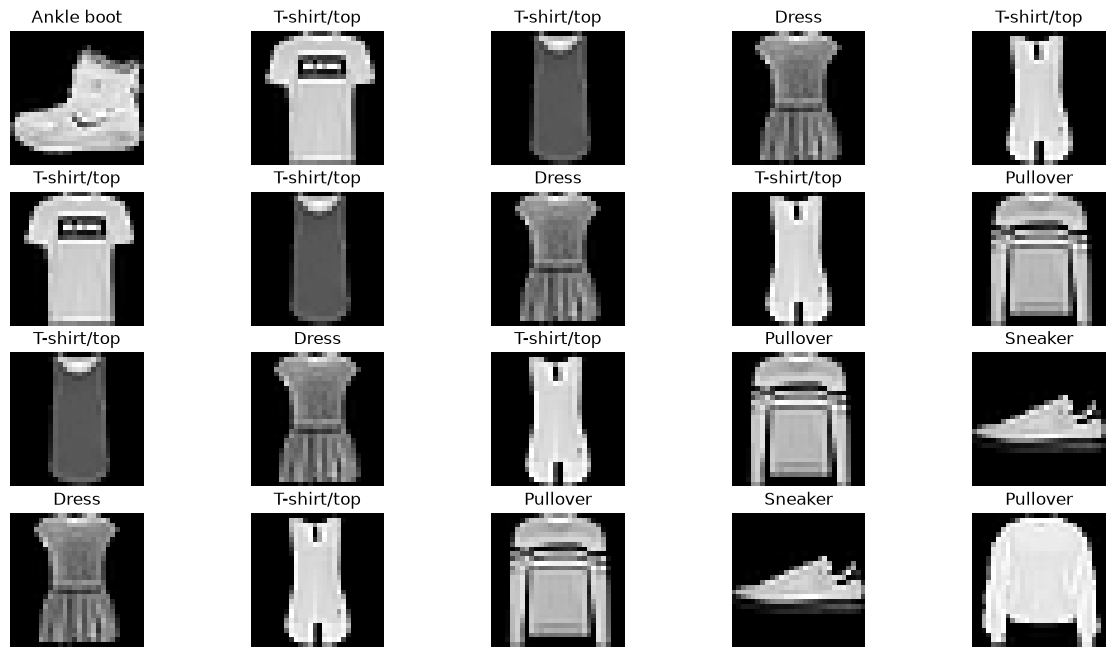

In [4]:
import matplotlib.pyplot as plt

class_labels: list[str] = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
fig, ax = plt.subplots(nrows=4, ncols=5, figsize=(15, 8))
for i in range(4):
    for j in range(5):
        ax[i, j].imshow(train_df[i+j][0].reshape(28, 28, 1), cmap='gray')
        ax[i, j].set_title(class_labels[train_df[i+j][1]])
        ax[i, j].set_axis_off()

In [5]:
# Neural network architecture
from torch import nn

class CustomModel(nn.Module):
    def __init__(self, num_features:int=1*28*28):
        super().__init__()

        self.model = nn.Sequential(
            nn.Flatten(start_dim=1, end_dim=-1), # from (1, 28, 28) → to (1, 784) since `start_dim = 1`
            
            nn.Linear(in_features=num_features, out_features=32),
            nn.GELU(),
            nn.BatchNorm1d(num_features=32),

            nn.Linear(in_features=32, out_features=16),
            nn.GELU(),
            nn.BatchNorm1d(num_features=16),

            nn.Linear(in_features=16, out_features=10)
        )

        self._initialize_weights()
    
    def _initialize_weights(self):
        """ Initialize weights using He initialization for ReLU networks """
        for module in self.modules():
            if isinstance(module, nn.Linear):
                nn.init.kaiming_normal_(module.weight, mode='fan_out', nonlinearity='relu')

                if module.bias is not None:
                    nn.init.constant_(module.bias, 0)

    def forward(self, features):
        return self.model(features)

In [6]:
# model summary
from torchinfo import summary

model: CustomModel = CustomModel(num_features=28*28).to(device)
summary(model=model, input_size=train_df[0][0].shape)

Layer (type:depth-idx)                   Output Shape              Param #
CustomModel                              [1, 10]                   --
├─Sequential: 1-1                        [1, 10]                   --
│    └─Flatten: 2-1                      [1, 784]                  --
│    └─Linear: 2-2                       [1, 32]                   25,120
│    └─GELU: 2-3                         [1, 32]                   --
│    └─BatchNorm1d: 2-4                  [1, 32]                   64
│    └─Linear: 2-5                       [1, 16]                   528
│    └─GELU: 2-6                         [1, 16]                   --
│    └─BatchNorm1d: 2-7                  [1, 16]                   32
│    └─Linear: 2-8                       [1, 10]                   170
Total params: 25,914
Trainable params: 25,914
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.03
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.10
Estimated Total Size (MB):

In [7]:
# Model Parameters
for name, param in model.named_parameters(): # 
    print(f"name: {name}")
    print(param, "\n")

name: model.1.weight
Parameter containing:
tensor([[ 0.1727, -0.2080,  0.1563,  ..., -0.1208, -0.3579, -0.0351],
        [-0.0715, -0.0822, -0.2050,  ..., -0.0298,  0.3771, -0.4679],
        [ 0.0294,  0.1046, -0.1064,  ..., -0.0204,  0.3009, -0.1131],
        ...,
        [ 0.1357, -0.1707, -0.4311,  ..., -0.0565, -0.0693,  0.1232],
        [-0.0165,  0.8494, -0.0599,  ..., -0.0535,  0.4767, -0.3061],
        [ 0.3619, -0.0487,  0.1145,  ...,  0.1607,  0.4617, -0.2897]],
       device='cuda:0', requires_grad=True) 

name: model.1.bias
Parameter containing:
tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0.], device='cuda:0', requires_grad=True) 

name: model.3.weight
Parameter containing:
tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       device='cuda:0', requires_grad=True) 

name: model.3.bias

In [8]:
# Model Buffers
for name, buffer in model.named_buffers(): # 
    print(f"name: {name}")
    print(buffer, "\n")

name: model.3.running_mean
tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0.], device='cuda:0') 

name: model.3.running_var
tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       device='cuda:0') 

name: model.3.num_batches_tracked
tensor(0, device='cuda:0') 

name: model.6.running_mean
tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       device='cuda:0') 

name: model.6.running_var
tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       device='cuda:0') 

name: model.6.num_batches_tracked
tensor(0, device='cuda:0') 



In [9]:
# Defining hyper-parameters, loss function and optimizer
learning_rate = 0.001
epochs = 10

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model.parameters(), lr=learning_rate, betas=(0.9, 0.999), weight_decay = 0.01)
model.train(mode=True) # set the module in training mode.

CustomModel(
  (model): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=32, bias=True)
    (2): GELU(approximate='none')
    (3): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (4): Linear(in_features=32, out_features=16, bias=True)
    (5): GELU(approximate='none')
    (6): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (7): Linear(in_features=16, out_features=10, bias=True)
  )
)

In [10]:
# Model Traning 
for epoch in range(epochs):
    # model's total loss over an entire dataset for one epoch
    total_loss = 0

    for batch_features, batch_labels in train_dataloader:
        optimizer.zero_grad()
        batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)
        y_pred = model(batch_features)

        loss = criterion(y_pred, batch_labels)
        loss.backward() # the optimization gets performed based on the per batch (mini-batch) loss (not per record (stocastic gd) or entire dataset (batch gd) loss) → mini-batch gradient optimization
        optimizer.step()

        total_loss += loss.item()
    
    avg_loss: float | Any = total_loss / (len(train_dataloader) * train_dataloader.batch_size) # average loss per image for visualization
    print(f'Epoch: {epoch + 1} , Loss: {avg_loss}')

Epoch: 1 , Loss: 0.012461535380914934
Epoch: 2 , Loss: 0.0075178987119219765
Epoch: 3 , Loss: 0.007119687664052491
Epoch: 4 , Loss: 0.0071227290294766585
Epoch: 5 , Loss: 0.007080346719224824
Epoch: 6 , Loss: 0.006939917986493693
Epoch: 7 , Loss: 0.006933580464455111
Epoch: 8 , Loss: 0.006951361474618793
Epoch: 9 , Loss: 0.006861980840402927
Epoch: 10 , Loss: 0.0068458135173753345


In [11]:
# Evaluation mode → essential to make any changes just for evaluation (dropout, batch_normalization)
model.eval()

CustomModel(
  (model): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=32, bias=True)
    (2): GELU(approximate='none')
    (3): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (4): Linear(in_features=32, out_features=16, bias=True)
    (5): GELU(approximate='none')
    (6): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (7): Linear(in_features=16, out_features=10, bias=True)
  )
)

In [12]:
# evaluation on test data
total = 0
correct = 0

with torch.no_grad():
    for batch_features, batch_labels in test_dataloader:
        batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

        outputs = model(batch_features)
        _, predicted = torch.max(input=outputs, dim=1) # returns (value, index)
        
        total += batch_labels.shape[0]
        correct += (predicted == batch_labels).sum().item()

print(f"Test Accuracy → {correct / total}")

Test Accuracy → 0.8472


Accuracy → 0.8472
Precision → tensor([0.7545, 0.9353, 0.7465, 0.8931, 0.7325, 0.9466, 0.6851, 0.9066, 0.9350,
        0.9222], device='cuda:0')
Recall → tensor([0.8760, 0.9690, 0.7450, 0.8190, 0.7860, 0.9210, 0.5330, 0.9220, 0.9640,
        0.9370], device='cuda:0')
F1-Score → tensor([0.8107, 0.9519, 0.7457, 0.8545, 0.7583, 0.9336, 0.5996, 0.9142, 0.9493,
        0.9296], device='cuda:0')



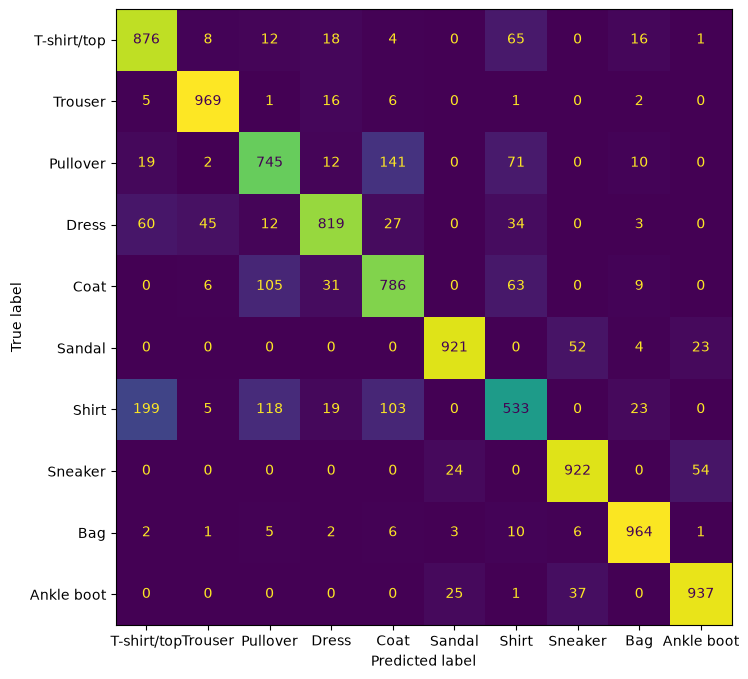

In [13]:
from torchmetrics.classification import (
    MulticlassAccuracy, 
    MulticlassPrecision, 
    MulticlassRecall, 
    MulticlassF1Score,
    MulticlassConfusionMatrix
)
from sklearn.metrics import ConfusionMatrixDisplay

# Initialize all metrics for 2 classes
accuracy = MulticlassAccuracy(num_classes=10).to(device)
precision = MulticlassPrecision(num_classes=10, average='none').to(device) # average='none' → precision per class
recall = MulticlassRecall(num_classes=10, average='none').to(device)
f1 = MulticlassF1Score(num_classes=10, average='none').to(device)
confusion_matrix = MulticlassConfusionMatrix(num_classes=10).to(device)

# Set model to evaluation mode
model.eval()

# Evaluation on test data
with torch.no_grad():
    for batch_features, batch_labels in test_dataloader:
        # Move data to device
        batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)
        
        # Get model predictions (logits)
        outputs = model(batch_features)  # Shape: [batch_size, 2]
        
        # Update all metrics with logits and true labels
        accuracy.update(outputs, batch_labels)
        precision.update(outputs, batch_labels)
        recall.update(outputs, batch_labels)
        f1.update(outputs, batch_labels)
        confusion_matrix.update(outputs, batch_labels)

# Compute final results
test_accuracy = accuracy.compute()
test_precision = precision.compute()
test_recall = recall.compute()
test_f1 = f1.compute()
conf_matrix = confusion_matrix.compute()

print(f"Accuracy → {test_accuracy:.4f}")
print(f"Precision → {test_precision}")
print(f"Recall → {test_recall}")
print(f"F1-Score → {test_f1}", end="\n\n")

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(19, 8))
disp = ConfusionMatrixDisplay(
    confusion_matrix=conf_matrix.cpu().numpy(), 
    display_labels=class_labels
)
disp.plot(ax=ax, colorbar=False)
plt.show()

In [14]:
# Saving model
checkpoint = {
    "epochs": epochs,
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "loss": criterion,
    "dropout_rate": 0.2
}
torch.save(obj=checkpoint, f="./model/model_checkpoint.pth")

In [15]:
# Loading model
model_checkpoint = torch.load(f="./model/model_checkpoint.pth", weights_only=False)

model = CustomModel().to(device)
model.load_state_dict(model_checkpoint["model_state_dict"])

criterion = model_checkpoint["loss"]

optimizer = torch.optim.Adam(params=model.parameters())
optimizer.load_state_dict(model_checkpoint["optimizer_state_dict"])

summary(model, input_size=train_df[0][0].shape)

Layer (type:depth-idx)                   Output Shape              Param #
CustomModel                              [1, 10]                   --
├─Sequential: 1-1                        [1, 10]                   --
│    └─Flatten: 2-1                      [1, 784]                  --
│    └─Linear: 2-2                       [1, 32]                   25,120
│    └─GELU: 2-3                         [1, 32]                   --
│    └─BatchNorm1d: 2-4                  [1, 32]                   64
│    └─Linear: 2-5                       [1, 16]                   528
│    └─GELU: 2-6                         [1, 16]                   --
│    └─BatchNorm1d: 2-7                  [1, 16]                   32
│    └─Linear: 2-8                       [1, 10]                   170
Total params: 25,914
Trainable params: 25,914
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.03
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.10
Estimated Total Size (MB):

In [16]:
# Model inference
model.eval()
_, index = torch.softmax(model(test_df[0][0].to(device)), dim=-1).max(dim=-1)
print(f"Predicted → {class_labels[index]}")
print(f"Actual → {class_labels[test_df[0][1]]}")

Predicted → Ankle boot
Actual → Ankle boot
